plots georeferenced UHI data 

In [7]:
import importlib
import sys
import os

sys.path.append(os.path.abspath("../"))

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

select transects

In [8]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

cube = transect.select_files(
    [
        "rad_uhi_20241029_115057_1",
        "rad_uhi_20241029_115057_2",
        "rad_uhi_20241029_115057_3",
        "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
    ]
)
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_1
  rad_uhi_20241029_115057_1: Using GRIDDED format (T=1333, S=968)
   • rad_uhi_20241029_115057_2
  rad_uhi_20241029_115057_2: Using GRIDDED format (T=1946, S=968)
   • rad_uhi_20241029_115057_3
  rad_uhi_20241029_115057_3: Using GRIDDED format (T=2227, S=968)
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using G

consider using qt or inline → the interactive mode for coordinates only work with qt

In [3]:
# %matplotlib qt

In [4]:
%matplotlib inline

plot complete georeferenced uhi

In [ ]:
# ========================================================================
# Full, self-contained module for georeferenced plotting with timestamps
# - Reads timestamps from HDF5 at "processed/radiance/timestamps" (preferred)
#   with safe fallbacks ("processed/timestamp", "timestamp", "timestamps")
# - Shows UTC time range for the plotted slice (whole plot or track_start/end)
# - Includes required helpers to avoid NameError (_ecef_to_ned_arrays, etc.)
# - Keeps the rest of logic/args/behavior intact
# ========================================================================

import os
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import h5py
import matplotlib.pyplot as Start scrolling. No, I said that the footprint itself should be black, and then everything else should be as the total already showed you. It's just adding a **** footprint, nothing else. Give me the monkey match. To run this code and then give me the code to actually run it. Finished. I. It's very **** easy. You look at this function here. Do you see that it has the time start of the transit time? I. I. I. You're not going to answer that. Hey, Cortana. Please. Hey, Cortana. This is 117 and then resentions. This is 117 and that was inches. Oh. I'll just give people **** What? I heard. Hey, Cortana. Hey, Cortana. plt
from pyproj import Transformer

# Optional config (if present in your environment). If not, it's fine.
try:
    from gref_pipeline import config  # noqa: F401
except Exception:
    config = None  # type: ignore


# ------------------------- CRS helpers -------------------------

def _ecef_of_geodetic(lat_deg: float, lon_deg: float, h_m: float) -> Tuple[float, float, float]:
    tf = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
    x0, y0, z0 = tf.transform(lon_deg, lat_deg, h_m)
    return float(x0), float(y0), float(z0)


def _ecef_to_ned_arrays(x, y, z, lat0, lon0, h0):
    """Vectorized ECEF -> NED (returns north, east, down) relative to (lat0, lon0, h0)."""
    x = np.asarray(x); y = np.asarray(y); z = np.asarray(z)
    x0, y0, z0 = _ecef_of_geodetic(lat0, lon0, h0)

    dx = x - x0
    dy = y - y0
    dz = z - z0

    lat = np.radians(lat0)
    lon = np.radians(lon0)

    sL = np.sin(lat); cL = np.cos(lat)
    sO = np.sin(lon); cO = np.cos(lon)

    n = (-sL * cO) * dx + (-sL * sO) * dy + (cL) * dz
    e = (-sO) * dx + (cO) * dy
    d = (-cL * cO) * dx + (-cL * sO) * dy + (-sL) * dz
    return n, e, d


def unix_to_utc(timestamp):
    """Convert unix timestamp to UTC string format."""
    from datetime import datetime
    try:
        return datetime.utcfromtimestamp(float(timestamp)).strftime("%Y-%m-%d %H:%M:%S UTC")
    except (ValueError, OSError, TypeError):
        return "N/A"


# ------------------------- Data wrappers -------------------------

class GeoFile:
    """
    Wraps a single H5 file containing (new pipeline outputs):
      - processed/radiance/dataCube(_corrected): (T, S, B)
      - processed/radiance/calibration/spectral/band2Wavelength
      - processed/georef/points_ecef_crs: (T, S, 3)  [preferred]
        (or legacy flattened: (N,3) + processed/georef/frame_indices & ray_indices)
      - processed/radiance/timestamps: (T,)  [preferred for time]
    """

    # dataset names
    DSET_RGB_MAIN = "processed/radiance/dataCube"
    DSET_RGB_CORR = "processed/radiance/dataCube_corrected"
    DSET_WAVELEN  = "processed/radiance/calibration/spectral/band2Wavelength"

    DSET_G_POINTS     = "processed/georef/points_ecef_crs"  # preferred
    DSET_G_POINTS_ALT = "processed/georef/points_ecef"      # legacy fallback

    # Legacy flattened format
    DSET_G_FRAMES      = "processed/georef/frame_indices"
    DSET_G_PIXELS      = "processed/georef/ray_indices"
    # New gridded indices (sometimes present)
    DSET_G_FRAMES_GRID = "processed/georef/frame_nr_grid"
    DSET_G_PIXELS_GRID = "processed/georef/pixel_nr_grid"

    # Timestamp datasets (preferred first)
    DSET_TIMESTAMPS = [
        "processed/radiance/timestamps",  # << primary path
        "processed/timestamp",
        "timestamp",
        "timestamps",
    ]

    def __init__(self, path: str, use_corrected: bool = False):
        self.path = path
        self.name = os.path.splitext(os.path.basename(path))[0]
        self.use_corrected = use_corrected

        self.shape: Optional[Tuple[int, int, int]] = None  # (T, S, B)
        self.wavelengths: Optional[np.ndarray] = None
        self.has_georef: bool = False
        self.timestamps: Optional[np.ndarray] = None  # Unix timestamps per track

        self._check()

    def _check(self):
        try:
            with h5py.File(self.path, "r") as f:
                # radiance cube
                dset_cube = self.DSET_RGB_CORR if self.use_corrected else self.DSET_RGB_MAIN
                if dset_cube not in f and self.DSET_RGB_MAIN in f:
                    dset_cube = self.DSET_RGB_MAIN
                    self.use_corrected = False
                if dset_cube in f:
                    self.shape = tuple(f[dset_cube].shape)  # (T,S,B)
                else:
                    self.shape = None

                # wavelengths
                self.wavelengths = f[self.DSET_WAVELEN][()] if self.DSET_WAVELEN in f else None

                # georef presence (grid is mainline, legacy points also accepted)
                pts_ok = (self.DSET_G_POINTS in f) or (self.DSET_G_POINTS_ALT in f)
                self.has_georef = bool(pts_ok)

                # timestamps (prefer processed/radiance/timestamps)
                for ts_path in self.DSET_TIMESTAMPS:
                    if ts_path in f:
                        self.timestamps = np.asarray(f[ts_path][()]).ravel()
                        break

        except Exception as e:
            print(f"⚠️  Could not read metadata from {self.name}: {e}")
            self.shape = None
            self.wavelengths = None
            self.has_georef = False
            self.timestamps = None

    def _band_index(self, wl_nm: float) -> Optional[int]:
        if self.wavelengths is None:
            return None
        return int(np.argmin(np.abs(self.wavelengths - wl_nm)))

    def build_grids_and_rgb(self, red_wl=654.2, green_wl=560.0, blue_wl=440.3) -> Dict[str, np.ndarray]:
        """
        Returns a dictionary with:
            X_ecef, Y_ecef, Z_ecef : (T, S)
            R, G, B                 : (T, S) floats (NaN where no hit)
            T, S                    : ints
        All grids have matching (T, S) derived from the radiance cube.
        """
        if self.shape is None:
            raise RuntimeError(f"{self.name}: radiance cube not found")
        T, S, B = self.shape

        dset_cube = self.DSET_RGB_CORR if self.use_corrected else self.DSET_RGB_MAIN

        X = np.full((T, S), np.nan, dtype=np.float64)
        Y = np.full((T, S), np.nan, dtype=np.float64)
        Z = np.full((T, S), np.nan, dtype=np.float64)
        R = np.full((T, S), np.nan, dtype=np.float64)
        G = np.full((T, S), np.nan, dtype=np.float64)
        Bc = np.full((T, S), np.nan, dtype=np.float64)

        with h5py.File(self.path, "r") as f:
            # georef points
            if self.DSET_G_POINTS in f:
                P = f[self.DSET_G_POINTS][()]
            elif self.DSET_G_POINTS_ALT in f:
                P = f[self.DSET_G_POINTS_ALT][()]
            else:
                raise RuntimeError(f"{self.name}: no processed/georef points dataset")

            if P.ndim == 3 and P.shape[-1] == 3:
                # GRIDDED FORMAT: (T, S, 3)
                X[:, :], Y[:, :], Z[:, :] = P[..., 0], P[..., 1], P[..., 2]

                # band indices
                iR = self._band_index(red_wl)
                iG = self._band_index(green_wl)
                iB = self._band_index(blue_wl)
                if iR is None or iG is None or iB is None:
                    raise RuntimeError(f"{self.name}: wavelengths not available")

                data = f[dset_cube][()]  # (T,S,B)
                R[:, :], G[:, :], Bc[:, :] = data[..., iR], data[..., iG], data[..., iB]

                # mask invalid geometry
                invalid = ~(np.isfinite(X) & np.isfinite(Y) & np.isfinite(Z))
                R[invalid] = np.nan; G[invalid] = np.nan; Bc[invalid] = np.nan

            elif P.ndim == 2 and P.shape[1] == 3:
                # LEGACY FLAT: (N,3) + indices
                if (self.DSET_G_FRAMES in f) and (self.DSET_G_PIXELS in f):
                    frames = f[self.DSET_G_FRAMES][()].astype(int)
                    slits  = f[self.DSET_G_PIXELS][()].astype(int)
                elif (self.DSET_G_FRAMES_GRID in f) and (self.DSET_G_PIXELS_GRID in f):
                    frames_grid = f[self.DSET_G_FRAMES_GRID][()]
                    slits_grid  = f[self.DSET_G_PIXELS_GRID][()]
                    if frames_grid.ndim == 2:
                        valid = np.isfinite(P[:, 0])
                        frames = frames_grid.ravel()[valid].astype(int)
                        slits  = slits_grid.ravel()[valid].astype(int)
                    else:
                        frames = frames_grid.astype(int)
                        slits  = slits_grid.astype(int)
                else:
                    raise RuntimeError(
                        f"{self.name}: flat points require frame_indices & pixel_indices"
                    )
                if len(frames) != len(P) or len(slits) != len(P):
                    raise RuntimeError(f"{self.name}: georef arrays length mismatch")

                iR = self._band_index(red_wl)
                iG = self._band_index(green_wl)
                iB = self._band_index(blue_wl)
                if iR is None or iG is None or iB is None:
                    raise RuntimeError(f"{self.name}: wavelengths not available")

                data = f[dset_cube]  # lazy

                for i in range(len(P)):
                    t = int(frames[i]); s = int(slits[i])
                    if 0 <= t < T and 0 <= s < S:
                        X[t, s] = P[i, 0]; Y[t, s] = P[i, 1]; Z[t, s] = P[i, 2]
                        R[t, s] = data[t, s, iR]
                        G[t, s] = data[t, s, iG]
                        Bc[t, s] = data[t, s, iB]
            else:
                raise RuntimeError(f"{self.name}: unexpected georef shape {P.shape}")

        return dict(X_ecef=X, Y_ecef=Y, Z_ecef=Z, R=R, G=G, B=Bc, T=T, S=S)


# ------------------------- Transect containers -------------------------

class TransectDataSet:
    """Discovers H5s in a folder and exposes selection helpers."""

    def __init__(self, folder: str, use_corrected: bool = False):
        self.folder = folder
        self.use_corrected = use_corrected
        self.files: Dict[str, GeoFile] = {}
        self._discover()

    def _discover(self):
        if not os.path.isdir(self.folder):
            print(f"❌ Folder not found: {self.folder}")
            return
        for fn in sorted(os.listdir(self.folder)):
            if not fn.lower().endswith(".h5"):
                continue
            path = os.path.join(self.folder, fn)
            gf = GeoFile(path, use_corrected=self.use_corrected)
            if gf.shape is not None and gf.has_georef:
                self.files[gf.name] = gf
            else:
                if gf.shape is not None:
                    print(f"⚠️  {fn}: radiance found but no georef dataset – skipped")
                else:
                    print(f"⚠️  {fn}: no radiance cube – skipped")

    def list_files(self):
        print(f"\n📋 Files in {os.path.basename(self.folder)} (corrected={self.use_corrected}):")
        for i, (name, gf) in enumerate(self.files.items(), 1):
            print(f"{i:2d}. {name}  | shape={gf.shape}  | has_georef={gf.has_georef}")
        if not self.files:
            print("  (none)")

    def select_files(self, names: List[str]) -> "CombinedTransectCube":
        missing = [n for n in names if n not in self.files]
        if missing:
            print(f"⚠️  Missing files: {missing}")
        chosen = [self.files[n] for n in names if n in self.files]
        if not chosen:
            raise ValueError("No valid files selected")
        return CombinedTransectCube(chosen, self.folder, self.use_corrected)

    def select_all_files(self) -> "CombinedTransectCube":
        return self.select_files(list(self.files.keys()))

    def select_files_by_pattern(self, pattern: str) -> "CombinedTransectCube":
        import fnmatch
        names = [n for n in self.files if fnmatch.fnmatch(n, pattern)]
        if not names:
            raise ValueError(f"No files match pattern: {pattern}")
        return self.select_files(names)


class CombinedTransectCube:
    """Combines multiple GeoFiles into a single logical cube along track."""

    def __init__(self, geofiles: List[GeoFile], folder: str, use_corrected: bool):
        self.geofiles = geofiles
        self.folder = folder
        self.use_corrected = use_corrected
        self.name = f"Combined_{os.path.basename(folder)}"
        self.file_boundaries = []  # list of dict with start_track etc.

        # combined grids (filled in on demand)
        self.X_ecef: Optional[np.ndarray] = None
        self.Y_ecef: Optional[np.ndarray] = None
        self.Z_ecef: Optional[np.ndarray] = None
        self.R: Optional[np.ndarray] = None
        self.G: Optional[np.ndarray] = None
        self.B: Optional[np.ndarray] = None
        self.wavelengths = geofiles[0].wavelengths if geofiles else None
        self.timestamps: Optional[np.ndarray] = None  # Combined timestamps

        self._build_combined()

    def _build_combined(self):
        print("🔄 Rebuilding grids from georef hits for selected files...")
        xs, ys, zs, rs, gs, bs = [], [], [], [], [], []
        timestamps_list = []
        T_accum = 0
        for gf in self.geofiles:
            print(f"   • {gf.name}")
            d = gf.build_grids_and_rgb()  # default RGB wavelengths; can re-run with kwargs in plot
            T, S = d["T"], d["S"]
            self.file_boundaries.append(
                {"file": gf.name, "start_track": T_accum, "end_track": T_accum + T - 1, "n_tracks": T}
            )
            xs.append(d["X_ecef"]); ys.append(d["Y_ecef"]); zs.append(d["Z_ecef"])
            rs.append(d["R"]); gs.append(d["G"]); bs.append(d["B"])

            # Collect timestamps; prefer exact length T, else pad/truncate
            if gf.timestamps is not None:
                ts = np.asarray(gf.timestamps).ravel()
                if len(ts) == T:
                    timestamps_list.append(ts)
                elif len(ts) > T:
                    timestamps_list.append(ts[:T])
                else:
                    pad = np.full(T, np.nan, dtype=float)
                    pad[: len(ts)] = ts
                    timestamps_list.append(pad)
            else:
                timestamps_list.append(np.full(T, np.nan, dtype=float))

            T_accum += T

        # combine along track axis
        self.X_ecef = np.concatenate(xs, axis=0)
        self.Y_ecef = np.concatenate(ys, axis=0)
        self.Z_ecef = np.concatenate(zs, axis=0)
        self.R      = np.concatenate(rs, axis=0)
        self.G      = np.concatenate(gs, axis=0)
        self.B      = np.concatenate(bs, axis=0)

        # Combine timestamps
        self.timestamps = np.concatenate(timestamps_list, axis=0) if timestamps_list else None

        print(f"✅ Combined shapes: X/Y/Z {self.X_ecef.shape}, RGB {self.R.shape}")

    def _rgb_from_wavelengths(self, Rnm, Gnm, Bnm, normalize):
        """Recompute R/G/B from requested wavelengths (without rebuilding georef)."""
        xs, ys, zs, rs, gs, bs = [], [], [], [], [], []
        for gf in self.geofiles:
            d = gf.build_grids_and_rgb(red_wl=Rnm, green_wl=Gnm, blue_wl=Bnm)
            xs.append(d["X_ecef"]); ys.append(d["Y_ecef"]); zs.append(d["Z_ecef"])
            rs.append(d["R"]); gs.append(d["G"]); bs.append(d["B"])
        X = np.concatenate(xs, axis=0)
        Y = np.concatenate(ys, axis=0)
        Z = np.concatenate(zs, axis=0)
        R = np.concatenate(rs, axis=0)
        G = np.concatenate(gs, axis=0)
        B = np.concatenate(bs, axis=0)

        if normalize:
            for C in (R, G, B):
                m, M = np.nanmin(C), np.nanmax(C)
                if np.isfinite(m) and np.isfinite(M) and M > m:
                    C[:] = (C - m) / (M - m)
        return X, Y, Z, R, G, B

    def _extract_rgb_from_cube(self, data_cube, Rnm, Gnm, Bnm):
        """Extract RGB channels from a full data cube (T, S, B) by wavelength."""
        gf = self.geofiles[0]
        iR = gf._band_index(Rnm); iG = gf._band_index(Gnm); iB = gf._band_index(Bnm)
        if iR is None or iG is None or iB is None:
            raise RuntimeError("Requested wavelengths not available")
        R = data_cube[:, :, iR]; G = data_cube[:, :, iG]; B = data_cube[:, :, iB]
        return R, G, B

    # ------------------- plotting -------------------

    def plot_georef(
        self,
        red_wl=654.2,
        green_wl=560.0,
        blue_wl=440.3,
        normalize=True,
        figsize=(11, 9),
        coordinate_system=None,  # "ECEF", "NED", "LATLON", or None (auto = LATLON)
        use_local_origin=True,   # only used when coordinate_system == "ECEF"
        origin=None,             # (lat, lon, h); required for NED/ECEF, ignored for LATLON
        show_file_boundaries=True,
        alpha_for_nodata=0.0,
        interactive=True,        # click to show coordinates
        track_start=None,        # inclusive
        track_end=None,          # exclusive
        use_corrected=False,     # use illumination corrected data if available
        # trajectory options (kept for compatibility; not changed here)
        show_trajectory=False,
        nav_csv_path=None,
        trajectory_color="red",
        trajectory_linewidth=2.0,
        trajectory_alpha=0.85,
        trajectory_decimate=1,
        return_fig=False,
        quiet=True,              # suppress non interactive prints and warnings
        **pcolor_kwargs,
    ):
        """
        RGB georeferenced composite in LATLON, NED, or ECEF.
        Adds UTC time information from processed/radiance/timestamps if available.
        """
        import io, contextlib, warnings

        def _silence():
            return contextlib.ExitStack()

        # Default display CRS
        if coordinate_system is None:
            coordinate_system = "LATLON"
        coord_sys = coordinate_system.upper()

        # Default origin for NED/ECEF
        if coord_sys in ["NED", "ECEF"]:
            if origin is None:
                if (config is not None) and hasattr(config, "LAT0") and hasattr(config, "LON0"):
                    origin = (
                        float(config.LAT0),
                        float(config.LON0),
                        float(getattr(config, "H0", 0.0)),
                    )
                else:
                    origin = (60.8011575, 10.7122345, 0.0)
        else:
            origin = None

        with _silence() as stack:
            if quiet:
                stack.enter_context(warnings.catch_warnings())
                warnings.simplefilter("ignore")
                stack.enter_context(contextlib.redirect_stdout(io.StringIO()))

            # Prepare grids & RGB
            if use_corrected:
                if not hasattr(self, "data_corrected") or self.data_corrected is None:
                    raise ValueError("Corrected data not available. Run apply_illumination_correction() first.")
                X_ecef, Y_ecef, Z_ecef = self.X_ecef, self.Y_ecef, self.Z_ecef
                R, G, B = self._extract_rgb_from_cube(self.data_corrected, red_wl, green_wl, blue_wl)
                if normalize:
                    for C in (R, G, B):
                        m, M = np.nanmin(C), np.nanmax(C)
                        if np.isfinite(m) and np.isfinite(M) and M > m:
                            C[:] = (C - m) / (M - m)
            else:
                X_ecef, Y_ecef, Z_ecef, R, G, B = self._rgb_from_wavelengths(
                    red_wl, green_wl, blue_wl, normalize
                )

        T_total, S = X_ecef.shape

        # Slice by track_start/end
        start_idx = track_start if track_start is not None else 0
        end_idx   = track_end if track_end is not None else T_total
        if start_idx < 0 or start_idx >= T_total:
            raise ValueError(f"track_start={start_idx} out of range [0, {T_total})")
        if end_idx <= start_idx or end_idx > T_total:
            raise ValueError(f"track_end={end_idx} must be in ({start_idx}, {T_total}]")

        X_ecef = X_ecef[start_idx:end_idx, :]
        Y_ecef = Y_ecef[start_idx:end_idx, :]
        Z_ecef = Z_ecef[start_idx:end_idx, :]
        R = R[start_idx:end_idx, :]
        G = G[start_idx:end_idx, :]
        B = B[start_idx:end_idx, :]
        T, S = X_ecef.shape

        # Build display coordinates
        if coord_sys == "LATLON":
            tf_ecef_to_geo = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
            lon, lat, height = tf_ecef_to_geo.transform(X_ecef, Y_ecef, Z_ecef)
            Xp, Yp = lon, lat
            xlabel, ylabel = "Longitude (°)", "Latitude (°)"
            valid_mask = np.isfinite(lon) & np.isfinite(lat)
            if valid_mask.any():
                lat0 = float(np.nanmean(lat[valid_mask]))
                lon0 = float(np.nanmean(lon[valid_mask]))
                title_origin = (lat0, lon0, 0.0)
            else:
                title_origin = (0.0, 0.0, 0.0)
        elif coord_sys == "NED":
            lat0, lon0, h0 = origin
            N, E, D = _ecef_to_ned_arrays(X_ecef, Y_ecef, Z_ecef, lat0, lon0, h0)
            Xp, Yp = E, N
            xlabel, ylabel = f"East (m) from {lat0}°, {lon0}°", "North (m)"
            title_origin = origin
        elif coord_sys == "ECEF":
            lat0, lon0, h0 = origin
            if use_local_origin:
                x0, y0, z0 = _ecef_of_geodetic(lat0, lon0, h0)
                Xp, Yp = X_ecef - x0, Y_ecef - y0
                xlabel, ylabel = f"ΔECEF X (m) from {lat0}°, {lon0}°", "ΔECEF Y (m)"
            else:
                Xp, Yp = X_ecef, Y_ecef
                xlabel, ylabel = "ECEF X (m)", "ECEF Y (m)"
            title_origin = origin
        else:
            raise ValueError("coordinate_system must be 'LATLON', 'NED', or 'ECEF'")

        # Compose RGB stack for plotting
        RGB = np.dstack([R, G, B]).astype(np.float64)
        alpha = np.ones((T, S), dtype=np.float64)
        alpha[~(np.isfinite(R) & np.isfinite(G) & np.isfinite(B))] = alpha_for_nodata
        RGB[alpha == 0] = np.nan

        # pcolormesh wants corners
        Xc = np.pad(Xp, ((0, 1), (0, 1)), mode="edge")
        Yc = np.pad(Yp, ((0, 1), (0, 1)), mode="edge")

        # Fill any invalid corners via nearest neighbor (robustness)
        mask_valid = np.isfinite(Xc) & np.isfinite(Yc)
        if not mask_valid.all():
            from scipy.ndimage import distance_transform_edt
            invalid_mask = ~mask_valid
            if invalid_mask.any():
                idx = distance_transform_edt(invalid_mask, return_distances=False, return_indices=True)
                Xc[invalid_mask] = Xc[tuple(idx[:, invalid_mask])]
                Yc[invalid_mask] = Yc[tuple(idx[:, invalid_mask])]

        # Plot
        fig, ax = plt.subplots(figsize=figsize)
        # Matplotlib allows an (M,N,3) or (M,N,4) array as C for pcolormesh in newer versions,
        # but to keep older behavior intact we'll pass the 3-channel array directly.
        ax.pcolormesh(Xc, Yc, RGB, shading="flat", **pcolor_kwargs)

        # File boundaries (only those inside the shown slice)
        if show_file_boundaries and len(self.file_boundaries) > 1:
            for b in self.file_boundaries[1:]:
                j_abs = b["start_track"]
                if start_idx <= j_abs < end_idx:
                    j = j_abs - start_idx
                    if 0 <= j < T:
                        ax.plot(
                            Xp[j, :],
                            Yp[j, :],
                            color="yellow",
                            linestyle=":",
                            linewidth=2,
                            alpha=0.9,
                        )

        # Aspect
        if coord_sys == "LATLON":
            if title_origin and title_origin[0] != 0:
                lat_center = title_origin[0]
                ax.set_aspect(1.0 / np.cos(np.radians(lat_center)), adjustable="box")
            else:
                ax.set_aspect("equal", adjustable="box")
        else:
            ax.set_aspect("equal", adjustable="box")

        # Title (with timestamp range if available)
        title = f"RGB georeferenced composite ({self.name}) [{coord_sys}]"
        if coord_sys == "LATLON":
            if title_origin:
                title += f"\ncenter ~ {title_origin[0]:.4f}°, {title_origin[1]:.4f}°"
        elif coord_sys == "NED" or (coord_sys == "ECEF" and use_local_origin):
            title += f"\norigin @ {title_origin[0]:.6f}°, {title_origin[1]:.6f}°"

        # Add UTC time range based on the plotted slice [start_idx:end_idx)
        if self.timestamps is not None and len(self.timestamps) > 0:
            ts = self.timestamps[max(0, start_idx) : max(0, end_idx)]
            if ts.size > 0:
                # first finite and last finite within slice
                start_time = next((unix_to_utc(v) for v in ts if np.isfinite(v)), "N/A")
                end_time   = next((unix_to_utc(v) for v in ts[::-1] if np.isfinite(v)), "N/A")
                title += f"\nTime: {start_time} → {end_time}"

        if interactive:
            title += "\n(Click to show coordinates)"
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        # Interactivity: click to print coordinates
        if interactive:
            tf_ecef_to_geo = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
            click_data = {
                "Xp": Xp, "Yp": Yp,
                "X_ecef": X_ecef, "Y_ecef": Y_ecef, "Z_ecef": Z_ecef,
                "R": R, "G": G, "B": B,
                "origin": origin,
                "coord_system": coord_sys,
                "use_local_origin": use_local_origin,
            }

            def on_click(event):
                if event.inaxes is None:
                    return
                x_click, y_click = event.xdata, event.ydata
                dist = (click_data["Xp"] - x_click) ** 2 + (click_data["Yp"] - y_click) ** 2
                try:
                    min_idx = np.nanargmin(dist)
                except Exception:
                    return
                ti, si = np.unravel_index(min_idx, click_data["Xp"].shape)
                x_plot = click_data["Xp"][ti, si]; y_plot = click_data["Yp"][ti, si]
                x_e = click_data["X_ecef"][ti, si]; y_e = click_data["Y_ecef"][ti, si]; z_e = click_data["Z_ecef"][ti, si]
                r_val = click_data["R"][ti, si]; g_val = click_data["G"][ti, si]; b_val = click_data["B"][ti, si]
                if not (np.isfinite(x_e) and np.isfinite(y_e) and np.isfinite(z_e)):
                    return
                lon_deg, lat_deg, height = tf_ecef_to_geo.transform(x_e, y_e, z_e)
                print("\n" + "=" * 70)
                print(f"📍 track={start_idx + ti}, slit={si}")
                if click_data["coord_system"] == "LATLON":
                    print(f"   Lat/Lon: {y_plot:.6f}°, {x_plot:.6f}°")
                elif click_data["coord_system"] == "NED":
                    print(f"   NED: E={x_plot:.2f} m, N={y_plot:.2f} m")
                else:
                    print(f"   Plot coords: ({x_plot:.2f}, {y_plot:.2f})")
                print(f"   ECEF: X={x_e:.2f} m, Y={y_e:.2f} m, Z={z_e:.2f} m")
                print(f"   WGS84: Lat={lat_deg:.6f}°, Lon={lon_deg:.6f}°, h={height:.2f} m")
                if np.isfinite(r_val):
                    print(f"   RGB: R={r_val:.3f}, G={g_val:.3f}, B={b_val:.3f}")
                else:
                    print("   RGB: No data")
                print("=" * 70)

            fig.canvas.mpl_connect("button_press_event", on_click)
            print("💡 Interactive mode: Click on the plot to display coordinates")

        fig.tight_layout()
        plt.show()
        return (fig, ax) if return_fig else None


# ------------------------- convenience -------------------------

def load_transect(folder_path: Optional[str] = None, use_corrected: bool = False) -> TransectDataSet:
    """
    Creates a TransectDataSet scanning the folder for H5s with georef outputs.
    If folder_path is None, uses config.OUTPUT_FOLDER when available.
    """
    if folder_path is None and config is not None and hasattr(config, "OUTPUT_FOLDER"):
        folder_path = config.OUTPUT_FOLDER
    if folder_path is None:
        raise ValueError("Provide folder_path or set config.OUTPUT_FOLDER")
    return TransectDataSet(folder_path, use_corrected=use_corrected)


In [13]:
def plot_georef(
    self,
    red_wl=654.2,
    green_wl=560.0,
    blue_wl=440.3,
    normalize=True,
    figsize=(11, 9),
    coordinate_system=None,  # "ECEF", "NED", "LATLON", or None (auto = LATLON)
    use_local_origin=True,  # only used when coordinate_system == "ECEF"
    origin=None,  # (lat, lon, h); required for NED/ECEF, ignored for LATLON
    show_file_boundaries=True,
    alpha_for_nodata=0.0,
    interactive=True,  # click to show coordinates
    track_start=None,  # inclusive
    track_end=None,  # exclusive
    use_corrected=False,  # use illumination corrected data if available
    # trajectory args kept for backwards compat (not used here)
    show_trajectory=False,
    nav_csv_path=None,
    trajectory_color="red",
    trajectory_linewidth=2.0,
    trajectory_alpha=0.85,
    trajectory_decimate=1,
    return_fig=False,
    quiet=True,  # suppress non interactive prints and warnings
    **pcolor_kwargs,
):
    """
    RGB georeferenced composite in LATLON, NED, or ECEF.

    IMPORTANT: Timestamp display uses self.timestamps, which must already be
    populated from the H5 at 'processed/radiance/timestamps' (preferred) or
    its fallbacks. We only slice it the same way as the track slice.
    """
    import io, contextlib, warnings
    import numpy as np
    import matplotlib.pyplot as plt
    from pyproj import Transformer

    # --- small helper for epoch unit robustness (sec/ms/ns) ---
    def _normalize_epoch_scalar(v):
        try:
            v = float(v)
        except Exception:
            return np.nan
        if v > 1e12:  # likely nanoseconds
            return v / 1e9
        elif v > 1e10:  # likely milliseconds
            return v / 1e3
        return v  # seconds

    def _silence():
        return contextlib.ExitStack()

    # Default display CRS
    if coordinate_system is None:
        coordinate_system = "LATLON"
    coord_sys = coordinate_system.upper()

    # Default origin for NED/ECEF
    if coord_sys in ["NED", "ECEF"]:
        if origin is None:
            if (
                ("config" in globals())
                and hasattr(config, "LAT0")
                and hasattr(config, "LON0")
            ):
                origin = (
                    float(config.LAT0),
                    float(config.LON0),
                    float(getattr(config, "H0", 0.0)),
                )
            else:
                origin = (60.8011575, 10.7122345, 0.0)
    else:
        origin = None

    with _silence() as stack:
        if quiet:
            stack.enter_context(warnings.catch_warnings())
            warnings.simplefilter("ignore")
            stack.enter_context(contextlib.redirect_stdout(io.StringIO()))

        # Prepare grids & RGB
        if use_corrected:
            if not hasattr(self, "data_corrected") or self.data_corrected is None:
                raise ValueError(
                    "Corrected data not available. Run apply_illumination_correction() first."
                )
            X_ecef, Y_ecef, Z_ecef = self.X_ecef, self.Y_ecef, self.Z_ecef
            R, G, B = self._extract_rgb_from_cube(
                self.data_corrected, red_wl, green_wl, blue_wl
            )
            if normalize:
                for C in (R, G, B):
                    m, M = np.nanmin(C), np.nanmax(C)
                    if np.isfinite(m) and np.isfinite(M) and M > m:
                        C[:] = (C - m) / (M - m)
        else:
            X_ecef, Y_ecef, Z_ecef, R, G, B = self._rgb_from_wavelengths(
                red_wl, green_wl, blue_wl, normalize
            )

    T_total, S = X_ecef.shape

    # Slice by track_start/end
    start_idx = track_start if track_start is not None else 0
    end_idx = track_end if track_end is not None else T_total
    if start_idx < 0 or start_idx >= T_total:
        raise ValueError(f"track_start={start_idx} out of range [0, {T_total})")
    if end_idx <= start_idx or end_idx > T_total:
        raise ValueError(f"track_end={end_idx} must be in ({start_idx}, {T_total}]")

    X_ecef = X_ecef[start_idx:end_idx, :]
    Y_ecef = Y_ecef[start_idx:end_idx, :]
    Z_ecef = Z_ecef[start_idx:end_idx, :]
    R = R[start_idx:end_idx, :]
    G = G[start_idx:end_idx, :]
    B = B[start_idx:end_idx, :]
    T, S = X_ecef.shape

    # Build display coordinates
    if coord_sys == "LATLON":
        tf_ecef_to_geo = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
        lon, lat, height = tf_ecef_to_geo.transform(X_ecef, Y_ecef, Z_ecef)
        Xp, Yp = lon, lat
        xlabel, ylabel = "Longitude (°)", "Latitude (°)"
        valid_mask = np.isfinite(lon) & np.isfinite(lat)
        if valid_mask.any():
            lat0 = float(np.nanmean(lat[valid_mask]))
            lon0 = float(np.nanmean(lon[valid_mask]))
            title_origin = (lat0, lon0, 0.0)
        else:
            title_origin = (0.0, 0.0, 0.0)
    elif coord_sys == "NED":
        lat0, lon0, h0 = origin
        N, E, D = _ecef_to_ned_arrays(X_ecef, Y_ecef, Z_ecef, lat0, lon0, h0)
        Xp, Yp = E, N
        xlabel, ylabel = f"East (m) from {lat0}°, {lon0}°", "North (m)"
        title_origin = origin
    elif coord_sys == "ECEF":
        lat0, lon0, h0 = origin
        if use_local_origin:
            x0, y0, z0 = _ecef_of_geodetic(lat0, lon0, h0)
            Xp, Yp = X_ecef - x0, Y_ecef - y0
            xlabel, ylabel = f"ΔECEF X (m) from {lat0}°, {lon0}°", "ΔECEF Y (m)"
        else:
            Xp, Yp = X_ecef, Y_ecef
            xlabel, ylabel = "ECEF X (m)", "ECEF Y (m)"
        title_origin = origin
    else:
        raise ValueError("coordinate_system must be 'LATLON', 'NED', or 'ECEF'")

    # Compose RGB stack for plotting
    RGB = np.dstack([R, G, B]).astype(np.float64)
    alpha = np.ones((T, S), dtype=np.float64)
    alpha[~(np.isfinite(R) & np.isfinite(G) & np.isfinite(B))] = alpha_for_nodata
    RGB[alpha == 0] = np.nan

    # pcolormesh wants corners
    Xc = np.pad(Xp, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Yp, ((0, 1), (0, 1)), mode="edge")

    # Fill any invalid corners via nearest neighbor
    mask_valid = np.isfinite(Xc) & np.isfinite(Yc)
    if not mask_valid.all():
        from scipy.ndimage import distance_transform_edt

        invalid_mask = ~mask_valid
        if invalid_mask.any():
            idx = distance_transform_edt(
                invalid_mask, return_distances=False, return_indices=True
            )
            Xc[invalid_mask] = Xc[tuple(idx[:, invalid_mask])]
            Yc[invalid_mask] = Yc[tuple(idx[:, invalid_mask])]

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.pcolormesh(Xc, Yc, RGB, shading="flat", **pcolor_kwargs)

    # File boundaries (only those inside the shown slice)
    if show_file_boundaries and len(self.file_boundaries) > 1:
        for b in self.file_boundaries[1:]:
            j_abs = b["start_track"]
            if start_idx <= j_abs < end_idx:
                j = j_abs - start_idx
                if 0 <= j < T:
                    ax.plot(
                        Xp[j, :],
                        Yp[j, :],
                        color="yellow",
                        linestyle=":",
                        linewidth=2,
                        alpha=0.9,
                    )

    # Aspect
    if coord_sys == "LATLON":
        if title_origin and title_origin[0] != 0:
            lat_center = title_origin[0]
            ax.set_aspect(1.0 / np.cos(np.radians(lat_center)), adjustable="box")
        else:
            ax.set_aspect("equal", adjustable="box")
    else:
        ax.set_aspect("equal", adjustable="box")

    # ----- Title (with timestamp slice) -----
    title = f"RGB georeferenced composite ({self.name}) [{coord_sys}]"
    if coord_sys == "LATLON":
        if title_origin:
            title += f"\ncenter ~ {title_origin[0]:.4f}°, {title_origin[1]:.4f}°"
    elif coord_sys == "NED" or (coord_sys == "ECEF" and use_local_origin):
        title += f"\norigin @ {title_origin[0]:.6f}°, {title_origin[1]:.6f}°"

    # Slice timestamps exactly the same way as tracks
    start_txt = "N/A"
    end_txt = "N/A"
    if (
        getattr(self, "timestamps", None) is not None
        and len(self.timestamps) >= end_idx
    ):
        ts_slice = np.asarray(self.timestamps[start_idx:end_idx]).ravel()
        # try to find the first/last finite after normalizing units
        if ts_slice.size > 0:
            ts_norm = np.array(
                [_normalize_epoch_scalar(v) for v in ts_slice], dtype=float
            )
            finite = np.isfinite(ts_norm)
            if finite.any():
                first = ts_norm[np.where(finite)[0][0]]
                last = ts_norm[np.where(finite)[0][-1]]
                start_txt = unix_to_utc(first)
                end_txt = unix_to_utc(last)

    title += f"\nTime (displayed): {start_txt} → {end_txt}"

    if interactive:
        title += "\n(Click to show coordinates)"
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Interactivity: click to print coordinates
    if interactive:
        tf_ecef_to_geo = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
        click_data = {
            "Xp": Xp,
            "Yp": Yp,
            "X_ecef": X_ecef,
            "Y_ecef": Y_ecef,
            "Z_ecef": Z_ecef,
            "R": R,
            "G": G,
            "B": B,
            "origin": origin,
            "coord_system": coord_sys,
            "use_local_origin": use_local_origin,
            "track_start_abs": start_idx,
        }

        def on_click(event):
            import numpy as np

            if event.inaxes is None:
                return
            x_click, y_click = event.xdata, event.ydata
            dist = (click_data["Xp"] - x_click) ** 2 + (click_data["Yp"] - y_click) ** 2
            try:
                min_idx = np.nanargmin(dist)
            except Exception:
                return
            ti, si = np.unravel_index(min_idx, click_data["Xp"].shape)
            x_plot = click_data["Xp"][ti, si]
            y_plot = click_data["Yp"][ti, si]
            x_e = click_data["X_ecef"][ti, si]
            y_e = click_data["Y_ecef"][ti, si]
            z_e = click_data["Z_ecef"][ti, si]
            r_val = click_data["R"][ti, si]
            g_val = click_data["G"][ti, si]
            b_val = click_data["B"][ti, si]
            if not (np.isfinite(x_e) and np.isfinite(y_e) and np.isfinite(z_e)):
                return
            lon_deg, lat_deg, height = tf_ecef_to_geo.transform(x_e, y_e, z_e)
            print("\n" + "=" * 70)
            print(f"📍 track={click_data['track_start_abs'] + ti}, slit={si}")
            if click_data["coord_system"] == "LATLON":
                print(f"   Lat/Lon: {y_plot:.6f}°, {x_plot:.6f}°")
            elif click_data["coord_system"] == "NED":
                print(f"   NED: E={x_plot:.2f} m, N={y_plot:.2f} m")
            else:
                print(f"   Plot coords: ({x_plot:.2f}, {y_plot:.2f})")
            print(f"   ECEF: X={x_e:.2f} m, Y={y_e:.2f} m, Z={z_e:.2f} m")
            print(f"   WGS84: Lat={lat_deg:.6f}°, Lon={lon_deg:.6f}°, h={height:.2f} m")
            if np.isfinite(r_val):
                print(f"   RGB: R={r_val:.3f}, G={g_val:.3f}, B={b_val:.3f}")
            else:
                print("   RGB: No data")
            print("=" * 70)

        fig.canvas.mpl_connect("button_press_event", on_click)
        if not quiet:
            print("💡 Interactive mode: Click on the plot to display coordinates")

    fig.tight_layout()
    plt.show()
    return (fig, ax) if return_fig else None


CombinedTransectCube.plot_georef = plot_georef

In [15]:
def plot_georef(
    self,
    red_wl=654.2,
    green_wl=560.0,
    blue_wl=440.3,
    normalize=True,
    figsize=(11, 9),
    coordinate_system=None,  # "ECEF", "NED", "LATLON", or None (auto = LATLON)
    use_local_origin=True,  # only used when coordinate_system == "ECEF"
    origin=None,  # (lat, lon, h); required for NED/ECEF, ignored for LATLON
    show_file_boundaries=True,
    alpha_for_nodata=0.0,
    interactive=True,  # click to show coordinates
    track_start=None,  # inclusive
    track_end=None,  # exclusive
    use_corrected=False,  # use illumination corrected data if available
    # (kept for API compatibility; not used here)
    show_trajectory=False,
    nav_csv_path=None,
    trajectory_color="red",
    trajectory_linewidth=2.0,
    trajectory_alpha=0.85,
    trajectory_decimate=1,
    return_fig=False,
    quiet=True,  # suppress non interactive prints/Warnings
    **pcolor_kwargs,
):
    """
    RGB georeferenced composite in LATLON, NED, or ECEF.

    Timestamp logic:
      1) If self.timestamps has usable values, slice it like tracks.
      2) Otherwise, for the plotted slice we open each overlapped H5 and read
         processed/radiance/timestamps (robust, case-insensitive fallbacks),
         then compute the displayed [start → end] in UTC.
    """
    import io, contextlib, warnings
    import numpy as np
    import matplotlib.pyplot as plt
    from pyproj import Transformer

    # ---------- helpers ----------
    def _normalize_epoch_scalar(v):
        """Handle sec / ms / µs / ns -> seconds (float)."""
        try:
            v = float(v)
        except Exception:
            return np.nan
        # thresholds chosen so 2020+ in various units land correctly
        if v > 1e15:  # micro/nano
            # try ns first; if still huge later we clip when converting to UTC
            return v / 1e9
        if v > 1e12:  # ms
            return v / 1e3
        return v  # seconds

    def _read_ts_from_file(h5_path):
        """Read timestamps array from a single H5 file with robust key search."""
        import h5py

        KEYS = [
            "processed/radiance/timestamps",  # preferred
            "processed/radiance/timestamp",
            "processed/timestamps",
            "processed/timestamp",
            "timestamps",
            "timestamp",
        ]
        with h5py.File(h5_path, "r") as f:
            # exact matches first
            for k in KEYS:
                if k in f:
                    return np.asarray(f[k][()]).ravel()
            # case-insensitive search inside processed/radiance
            try:
                grp = f["processed"]["radiance"]
                for name, obj in grp.items():
                    if hasattr(obj, "shape") and "timestamp" in name.lower():
                        return np.asarray(obj[()]).ravel()
            except Exception:
                pass

            # global fall-back: any dataset containing 'timestamp'
            def _walk(g):
                for k, v in g.items():
                    if hasattr(v, "shape"):
                        if "timestamp" in k.lower():
                            return np.asarray(v[()]).ravel()
                    if isinstance(v, type(g)):
                        out = _walk(v)
                        if out is not None:
                            return out
                return None

            out = _walk(f)
            return out if out is not None else np.array([], dtype=float)

    def _utc_range_for_slice(start_idx, end_idx):
        """Return (start_txt, end_txt) for plotted slice using self.timestamps or per-file H5 read."""
        # 1) try self.timestamps
        ts = getattr(self, "timestamps", None)
        if ts is not None and len(ts) >= end_idx:
            sl = np.asarray(ts[start_idx:end_idx]).ravel()
            if sl.size:
                sln = np.array([_normalize_epoch_scalar(v) for v in sl], dtype=float)
                finite = np.isfinite(sln)
                if finite.any():
                    first = sln[np.where(finite)[0][0]]
                    last = sln[np.where(finite)[0][-1]]
                    return unix_to_utc(first), unix_to_utc(last)

        # 2) robust per-file read just for the overlapped range
        parts = []
        # self.file_boundaries is a list of dicts with start_track/end_track/n_tracks/file
        # self.geofiles holds GeoFile objects with .name and .path
        name_to_gf = {gf.name: gf for gf in self.geofiles}
        for b in self.file_boundaries:
            f_start = b["start_track"]
            f_end = b["end_track"] + 1  # exclusive
            # overlap with [start_idx, end_idx)
            a = max(start_idx, f_start)
            z = min(end_idx, f_end)
            if a >= z:
                continue
            gf = name_to_gf[b["file"]]
            full_ts = _read_ts_from_file(gf.path)
            if full_ts.size == 0:
                # no timestamps in this file
                parts.append(np.full(z - a, np.nan))
                continue
            # align lengths: georef tracks for file = b["n_tracks"]
            # cut relative window within this file
            rel0 = a - f_start
            rel1 = rel0 + (z - a)
            rel0 = max(0, rel0)
            rel1 = min(len(full_ts), rel1)
            seg = full_ts[rel0:rel1]
            if len(seg) < (z - a):
                pad = np.full((z - a,), np.nan)
                pad[: len(seg)] = seg
                seg = pad
            parts.append(np.asarray(seg))
        if parts:
            sl = np.concatenate(parts).ravel()
            sln = np.array([_normalize_epoch_scalar(v) for v in sl], dtype=float)
            finite = np.isfinite(sln)
            if finite.any():
                first = sln[np.where(finite)[0][0]]
                last = sln[np.where(finite)[0][-1]]
                return unix_to_utc(first), unix_to_utc(last)
        return "N/A", "N/A"

    def _silence():
        return contextlib.ExitStack()

    # ---------- defaults ----------
    if coordinate_system is None:
        coordinate_system = "LATLON"
    coord_sys = coordinate_system.upper()

    if coord_sys in ["NED", "ECEF"]:
        if origin is None:
            if (
                ("config" in globals())
                and hasattr(config, "LAT0")
                and hasattr(config, "LON0")
            ):
                origin = (
                    float(config.LAT0),
                    float(config.LON0),
                    float(getattr(config, "H0", 0.0)),
                )
            else:
                origin = (60.8011575, 10.7122345, 0.0)
    else:
        origin = None

    # ---------- data prep ----------
    with _silence() as stack:
        if quiet:
            stack.enter_context(warnings.catch_warnings())
            warnings.simplefilter("ignore")
            stack.enter_context(contextlib.redirect_stdout(io.StringIO()))

        if use_corrected:
            if not hasattr(self, "data_corrected") or self.data_corrected is None:
                raise ValueError(
                    "Corrected data not available. Run apply_illumination_correction() first."
                )
            X_ecef, Y_ecef, Z_ecef = self.X_ecef, self.Y_ecef, self.Z_ecef
            R, G, B = self._extract_rgb_from_cube(
                self.data_corrected, red_wl, green_wl, blue_wl
            )
            if normalize:
                for C in (R, G, B):
                    m, M = np.nanmin(C), np.nanmax(C)
                    if np.isfinite(m) and np.isfinite(M) and M > m:
                        C[:] = (C - m) / (M - m)
        else:
            X_ecef, Y_ecef, Z_ecef, R, G, B = self._rgb_from_wavelengths(
                red_wl, green_wl, blue_wl, normalize
            )

    T_total, S = X_ecef.shape

    # slice
    start_idx = track_start if track_start is not None else 0
    end_idx = track_end if track_end is not None else T_total
    if start_idx < 0 or start_idx >= T_total:
        raise ValueError(f"track_start={start_idx} out of range [0, {T_total})")
    if end_idx <= start_idx or end_idx > T_total:
        raise ValueError(f"track_end={end_idx} must be in ({start_idx}, {T_total}]")

    X_ecef = X_ecef[start_idx:end_idx, :]
    Y_ecef = Y_ecef[start_idx:end_idx, :]
    Z_ecef = Z_ecef[start_idx:end_idx, :]
    R = R[start_idx:end_idx, :]
    G = G[start_idx:end_idx, :]
    B = B[start_idx:end_idx, :]
    T, S = X_ecef.shape

    # display coords
    if coord_sys == "LATLON":
        tf_ecef_to_geo = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
        lon, lat, _ = tf_ecef_to_geo.transform(X_ecef, Y_ecef, Z_ecef)
        Xp, Yp = lon, lat
        xlabel, ylabel = "Longitude (°)", "Latitude (°)"
        valid_mask = np.isfinite(lon) & np.isfinite(lat)
        if valid_mask.any():
            lat0 = float(np.nanmean(lat[valid_mask]))
            lon0 = float(np.nanmean(lon[valid_mask]))
            title_origin = (lat0, lon0, 0.0)
        else:
            title_origin = (0.0, 0.0, 0.0)
    elif coord_sys == "NED":
        lat0, lon0, h0 = origin
        N, E, D = _ecef_to_ned_arrays(X_ecef, Y_ecef, Z_ecef, lat0, lon0, h0)
        Xp, Yp = E, N
        xlabel, ylabel = f"East (m) from {lat0}°, {lon0}°", "North (m)"
        title_origin = origin
    elif coord_sys == "ECEF":
        lat0, lon0, h0 = origin
        if use_local_origin:
            x0, y0, z0 = _ecef_of_geodetic(lat0, lon0, h0)
            Xp, Yp = X_ecef - x0, Y_ecef - y0
            xlabel, ylabel = f"ΔECEF X (m) from {lat0}°, {lon0}°", "ΔECEF Y (m)"
        else:
            Xp, Yp = X_ecef, Y_ecef
            xlabel, ylabel = "ECEF X (m)", "ECEF Y (m)"
        title_origin = origin
    else:
        raise ValueError("coordinate_system must be 'LATLON', 'NED', or 'ECEF'")

    # draw
    RGB = np.dstack([R, G, B]).astype(np.float64)
    alpha = np.ones((T, S), dtype=np.float64)
    alpha[~(np.isfinite(R) & np.isfinite(G) & np.isfinite(B))] = alpha_for_nodata
    RGB[alpha == 0] = np.nan

    Xc = np.pad(Xp, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Yp, ((0, 1), (0, 1)), mode="edge")

    mask_valid = np.isfinite(Xc) & np.isfinite(Yc)
    if not mask_valid.all():
        from scipy.ndimage import distance_transform_edt

        invalid = ~mask_valid
        if invalid.any():
            idx = distance_transform_edt(
                invalid, return_distances=False, return_indices=True
            )
            Xc[invalid] = Xc[tuple(idx[:, invalid])]
            Yc[invalid] = Yc[tuple(idx[:, invalid])]

    fig, ax = plt.subplots(figsize=figsize)
    ax.pcolormesh(Xc, Yc, RGB, shading="flat", **pcolor_kwargs)

    # file boundaries inside slice
    if show_file_boundaries and len(self.file_boundaries) > 1:
        for b in self.file_boundaries[1:]:
            j_abs = b["start_track"]
            if start_idx <= j_abs < end_idx:
                j = j_abs - start_idx
                if 0 <= j < T:
                    ax.plot(
                        Xp[j, :],
                        Yp[j, :],
                        color="yellow",
                        linestyle=":",
                        linewidth=2,
                        alpha=0.9,
                    )

    # aspect
    if coord_sys == "LATLON":
        if title_origin and title_origin[0] != 0:
            lat_center = title_origin[0]
            ax.set_aspect(1.0 / np.cos(np.radians(lat_center)), adjustable="box")
        else:
            ax.set_aspect("equal", adjustable="box")
    else:
        ax.set_aspect("equal", adjustable="box")

    # title + timestamps
    title = f"RGB georeferenced composite ({self.name}) [{coord_sys}]"
    if coord_sys == "LATLON":
        if title_origin:
            title += f"\ncenter ~ {title_origin[0]:.4f}°, {title_origin[1]:.4f}°"
    elif coord_sys == "NED" or (coord_sys == "ECEF" and use_local_origin):
        title += f"\norigin @ {title_origin[0]:.6f}°, {title_origin[1]:.6f}°"

    t0_txt, t1_txt = _utc_range_for_slice(start_idx, end_idx)
    title += f"\nTime (displayed): {t0_txt} → {t1_txt}"
    if interactive:
        title += "\n(Click to show coordinates)"
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # click readout
    if interactive:
        tf_ecef_to_geo = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
        click_data = {
            "Xp": Xp,
            "Yp": Yp,
            "X_ecef": X_ecef,
            "Y_ecef": Y_ecef,
            "Z_ecef": Z_ecef,
            "R": R,
            "G": G,
            "B": B,
            "origin": origin,
            "coord_system": coord_sys,
            "use_local_origin": use_local_origin,
            "track_start_abs": start_idx,
        }

        def on_click(event):
            import numpy as np

            if event.inaxes is None:
                return
            x_click, y_click = event.xdata, event.ydata
            dist = (click_data["Xp"] - x_click) ** 2 + (click_data["Yp"] - y_click) ** 2
            try:
                min_idx = np.nanargmin(dist)
            except Exception:
                return
            ti, si = np.unravel_index(min_idx, click_data["Xp"].shape)
            x_plot, y_plot = click_data["Xp"][ti, si], click_data["Yp"][ti, si]
            x_e, y_e, z_e = (
                click_data["X_ecef"][ti, si],
                click_data["Y_ecef"][ti, si],
                click_data["Z_ecef"][ti, si],
            )
            r_val, g_val, b_val = (
                click_data["R"][ti, si],
                click_data["G"][ti, si],
                click_data["B"][ti, si],
            )
            if not (np.isfinite(x_e) and np.isfinite(y_e) and np.isfinite(z_e)):
                return
            lon_deg, lat_deg, height = tf_ecef_to_geo.transform(x_e, y_e, z_e)
            print("\n" + "=" * 70)
            print(f"📍 track={click_data['track_start_abs'] + ti}, slit={si}")
            if click_data["coord_system"] == "LATLON":
                print(f"   Lat/Lon: {y_plot:.6f}°, {x_plot:.6f}°")
            elif click_data["coord_system"] == "NED":
                print(f"   NED: E={x_plot:.2f} m, N={y_plot:.2f} m")
            else:
                print(f"   Plot coords: ({x_plot:.2f}, {y_plot:.2f})")
            print(f"   ECEF: X={x_e:.2f} m, Y={y_e:.2f} m, Z={z_e:.2f} m")
            print(f"   WGS84: Lat={lat_deg:.6f}°, Lon={lon_deg:.6f}°, h={height:.2f} m")
            if np.isfinite(r_val):
                print(f"   RGB: R={r_val:.3f}, G={g_val:.3f}, B={b_val:.3f}")
            else:
                print("   RGB: No data")
            print("=" * 70)

        fig.canvas.mpl_connect("button_press_event", on_click)

    fig.tight_layout()
    plt.show()
    return (fig, ax) if return_fig else None

In [16]:
CombinedTransectCube.plot_georef = plot_georef

💡 Interactive mode: Click on the plot to display coordinates


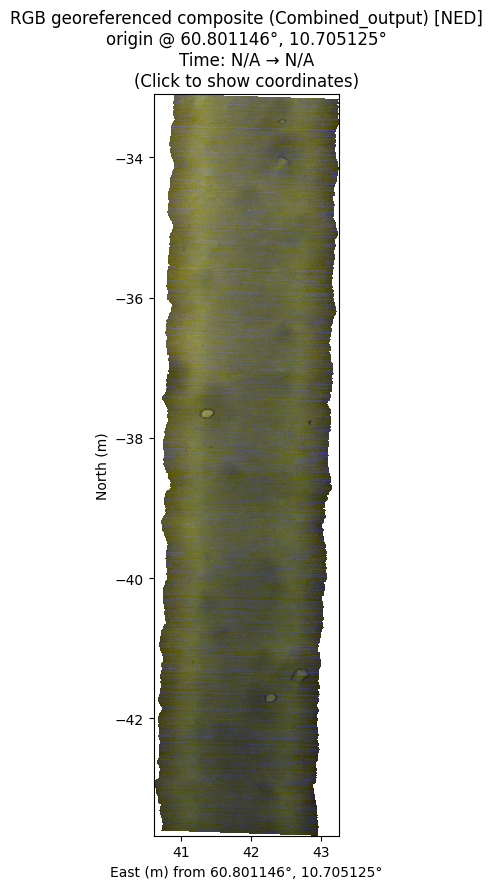

In [17]:
cube.plot_georef(
    coordinate_system="NED",
    track_start=8637,
    track_end=9709,
)

💡 Interactive mode: Click on the plot to display coordinates


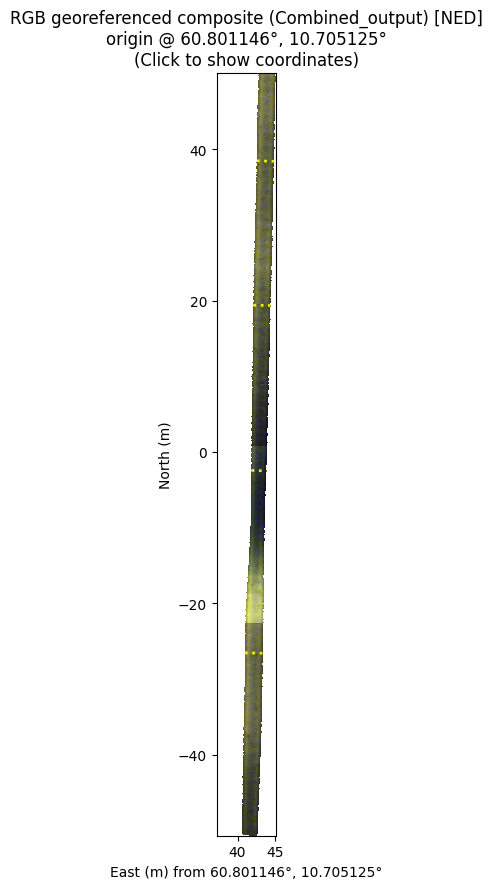

In [5]:
cube.plot_georef(coordinate_system="NED", interactive=True)

show with trajectory (require qt)

In [6]:
# Option 1: LATLON mode with trajectory (default)

%matplotlib qt
fig, ax = cube.plot_georef_with_trajectory(
    coordinate_system="LATLON",  # or None
    show_trajectory=True,
    trajectory_color="red",
    trajectory_linewidth=1.5,
    trajectory_alpha=0.7,
    interactive=True,
)

Loaded 232670 navigation records from E:\mjosa_new\navigation_data\nav_data_merged.csv
Time range: 1730196822.84 to 1730207699.44
✓ Added trajectory with 232670 points


get stats for entire transect

In [ ]:
print_processing_statistics()

PROCESSING STATISTICS

📅 SESSION INFO
  Started: 2025-10-11 16:35:10
  Finished: 2025-10-11 16:44:08
  Processing duration: 8m 57s

⚙️  CONFIGURATION
  Navigation CSV: nav_data_merged.csv
  MBES GeoTIFF: geotiff_2.tif
  Output folder: output
  Max ray length: 100.0 m
  Failure threshold: 50.0%

🧭 NAVIGATION DATA
  Total records: 232,670 (navigation data points in CSV)
  Start time: 1730196822.84 (2024-10-29 10:13:42 UTC)
  End time: 1730207699.44 (2024-10-29 13:14:59 UTC)
  Duration: 10876.6 s (181.3 min)

🗺️  MBES MESH
  Vertices: 7,390,592
  Faces: 7,383,936
  Bounds (X): [592829.45, 592857.59] m
  Bounds (Y): [6741790.71, 6741895.67] m
  Bounds (Z): [-136.01, -110.83] m

📷 CAMERA CALIBRATION
  Focal length: 930.63 px
  Principal point: 484.75 px
  Image width: 968 px

📊 COMBINED TRANSECT STATISTICS (All H5 files together)

  Files processed: 6 total
    ✅ Successful: 6
    ❌ Failed: 0

  HSI Data:
    Total frames: 10,586
    Total rays: 10,247,248
    Successful hits: 10,094,582
  

{'processing_session': {'start_time': '2025-10-11 16:35:10',
  'end_time': '2025-10-11 16:44:08',
  'duration_sec': 537.849462,
  'duration_human': '8m 57s'},
 'configuration': {'nav_csv': 'E:\\mjosa_new\\navigation_data\\nav_data_merged.csv',
  'mbes_geotiff': 'E:\\mjosa_new\\DTM\\geotiff_2.tif',
  'camera_calib_xml': 'E:\\mjosa_new_oct_2025\\anxillary_data\\HSI_2_body.xml',
  'output_folder': 'E:\\mjosa_new_oct_2025\\use_gref4hsi\\057_final\\output',
  'max_ray_length_m': 100.0,
  'early_failure_threshold_pct': 50.0,
  'epsg_mbes': 32632,
  'sensor_translation': [0.0, -2.5, 0.0],
  'sensor_rotation': [[0.0, 1.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, -1.0]]},
 'navigation_data': {'total_records': 232670,
  'time_range': {'start': 1730196822.8426645,
   'end': 1730207699.4423833,
   'duration_sec': 10876.599718809128}},
 'mbes_mesh': {'n_vertices': 7390592,
  'n_faces': 7383936,
  'bounds': {'x_min': 592829.45,
   'x_max': 592857.59,
   'y_min': 6741790.71,
   'y_max': 6741895.67,
   'z_mi

: 

plot segment with bombs only

In [ ]:
cube.apply_illumination_correction()

🔄 Computing illumination correction: rolling (window=1000), strength=1.0


   Processing slits: 100%|██████████| 968/968 [11:33<00:00,  1.40slit/s]


✅ data_corrected ready (rolling (window=1000))
💾 Saving illumination correction to 5 files...
   ✓ rad_uhi_20241029_115057_1: saved (1333, 968, 210)
   ✓ rad_uhi_20241029_115057_2: saved (1946, 968, 210)
   ✓ rad_uhi_20241029_115057_3: saved (2227, 968, 210)


💡 Interactive mode: Click on the plot to display coordinates


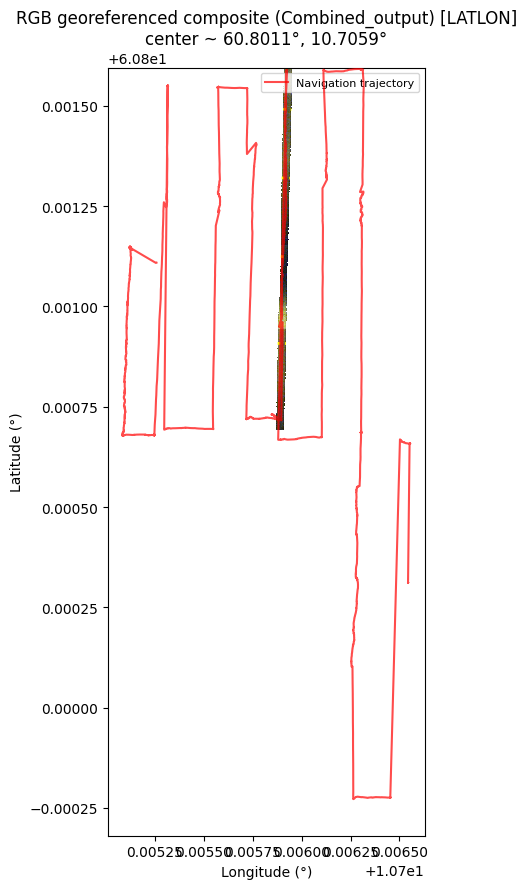

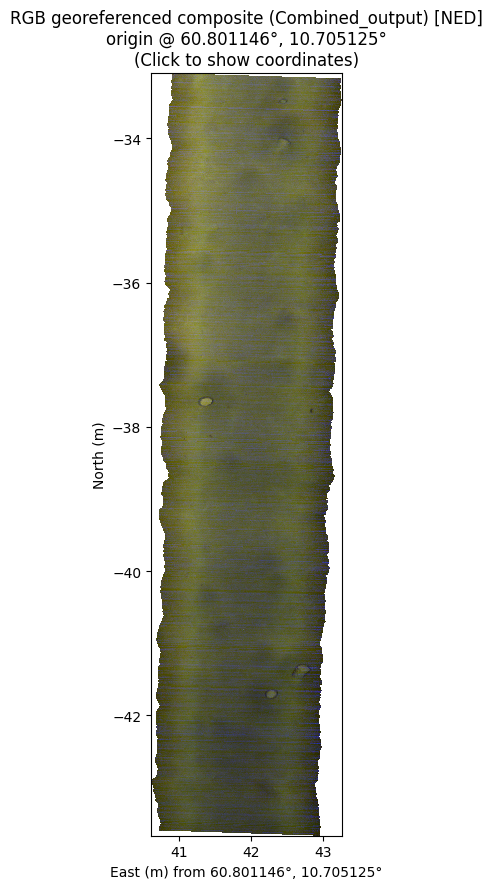

💡 Interactive mode: Click on the plot to display coordinates


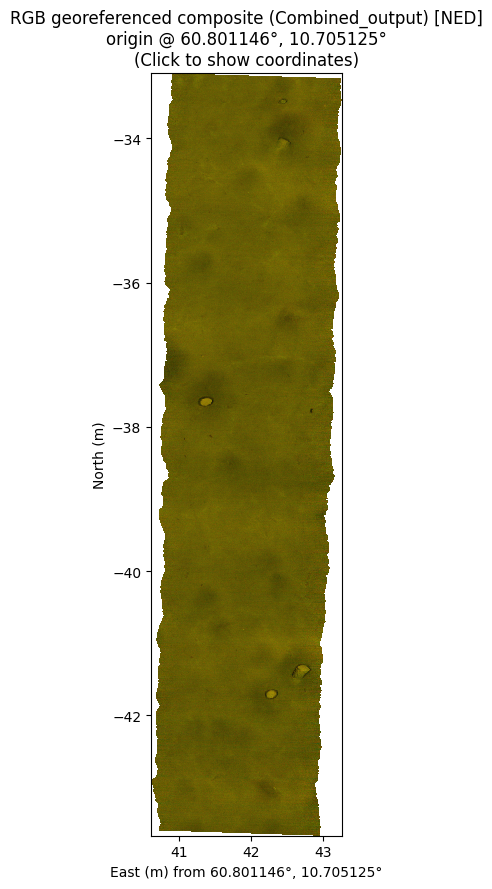

In [ ]:
%matplotlib inline
# %matplotlib qt

cube.plot_georef(
    coordinate_system="NED",
    show_file_boundaries=True,
    interactive=True,
    track_start=8637,
    track_end=9709,
)

cube.plot_georef(
    coordinate_system="NED",
    show_file_boundaries=True,
    interactive=True,
    track_start=8637,
    track_end=9709,
    use_corrected=True,
)